In [1]:
import pymysql
import pandas as pd
from typing import List, Dict, Optional, Tuple
from DATA.stock_invest_function import get_db_host


In [2]:
def fetch_required_return_from_db(
    db_info: Dict[str, any],
    ticker: str,
    indicator: str = "Re_5y",
    table_name: str = "us_required_return_result"
) -> pd.DataFrame:
    """
    us_required_return_result 테이블에서 특정 ticker, indicator(Re_5y)의 시계열 추출

    return: DataFrame index=date, columns=['Re_5y']
    """
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info.get("port", 3306),
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        sql = f"""
        SELECT date, value
        FROM {table_name}
        WHERE ticker=%s AND indicator=%s
        ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker, indicator])
    finally:
        conn.close()

    if df.empty:
        raise ValueError(f"[Re] {ticker} / {indicator} 데이터가 없습니다.")

    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    df = df.rename(columns={"value": indicator})

    return df

def fetch_roe_from_sec_financial(
    db_info: Dict[str, any],
    ticker: str,
    item_name: str = "ROE",
    table_name: str = "sec_financial_data"
) -> pd.DataFrame:
    """
    sec_financial_data 에서 특정 ticker, item_name(ROE)의 시계열 추출

    return: DataFrame index=date, columns=['ROE']
    """
    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info.get("port", 3306),
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        sql = f"""
        SELECT date, value
        FROM {table_name}
        WHERE ticker=%s AND item_name=%s
        ORDER BY date
        """
        df = pd.read_sql(sql, conn, params=[ticker, item_name])
    finally:
        conn.close()

    if df.empty:
        raise ValueError(f"[ROE] {ticker} / {item_name} 데이터가 없습니다.")

    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    df = df.rename(columns={"value": item_name})

    # ROE가 % 단위(예: 12, 15 등)이면 0.x 로 스케일 조정
    med = df[item_name].median()
    if med > 1 and med < 100:
        df[item_name] = df[item_name] / 100.0

    return df

def get_latest_book_value_from_sec_financial(
    db_info: Dict[str, any],
    ticker: str,
    item_name: str = "stockholders_equity",
    table_name: str = "sec_financial_data"
) -> float:
    """
    sec_financial_data 테이블에서 특정 ticker 의 가장 최신 stockholders_equity 값을 반환.
    이 값은 RIM valuation 의 초기 book_value 로 사용됨.
    """

    conn = pymysql.connect(
        host=db_info["host"],
        port=db_info.get("port", 3306),
        user=db_info["user"],
        password=db_info["password"],
        database=db_info["database"],
        charset="utf8mb4"
    )

    try:
        sql = f"""
        SELECT date, value
        FROM {table_name}
        WHERE ticker=%s AND item_name=%s
        ORDER BY date DESC
        LIMIT 1
        """
        df = pd.read_sql(sql, conn, params=[ticker, item_name])
    finally:
        conn.close()

    if df.empty:
        raise ValueError(f"[ERROR] {ticker}: stockholders_equity 최신 값이 없습니다.")

    book_value = float(df["value"].iloc[0])
    print(f"[INFO] {ticker} 최신 Book Value(stockholders_equity): {book_value:,.0f}")

    return book_value



def build_monthly_roe_re(
    db_info: Dict[str, any],
    ticker: str,
    re_indicator: str = "Re_5y",
    roe_item_name: str = "ROE"
) -> pd.DataFrame:
    """
    1) us_required_return_result 에서 Re_5y
    2) sec_financial_data 에서 ROE
    → 둘 다 월말 기준으로 resample 후 merge

    return: DataFrame index=date(月末), columns=['ROE','Re_5y','spread']
    """
    re_df = fetch_required_return_from_db(db_info, ticker, indicator=re_indicator)
    roe_df = fetch_roe_from_sec_financial(db_info, ticker, item_name=roe_item_name)

    # 월말 기준 resample (값이 없는 달은 직전값 유지)
    re_m  = re_df.resample("M").last().ffill()
    roe_m = roe_df.resample("M").last().ffill()

    merged = roe_m.join(re_m, how="inner")

    merged = merged.rename(columns={roe_item_name: "ROE", re_indicator: "Re_5y"})
    merged["spread"] = merged["ROE"] - merged["Re_5y"]

    return merged


def residual_income_valuation(
    initial_book_value: float,
    current_roe: float,
    required_return: float,
    payout_ratio: float = 0.3,
    n_high_years: int = 5,
    n_fade_years: int = 10,
    terminal_spread: float = 0.0
) -> Tuple[pd.DataFrame, float]:
    """
    단순 다단계 RIM 모형

    - 1 ~ n_high_years : ROE = current_roe
    - n_high_years+1 ~ n_high_years+n_fade_years :
        ROE가 선형으로 required_return + terminal_spread 로 수렴
    - 이후 기간의 RI 는 terminal_spread 를 반영한 '안정기 RI'의 영구가치로 처리

    return
    ------
    ri_table : 연도별 잔여이익 테이블
    fair_value : 주당 또는 총 자기자본 가치 (B0 + PV(RI))
    """

    T = n_high_years + n_fade_years  # 명시적으로 계산할 기간
    rows = []

    B_t = initial_book_value
    re = required_return

    # 안정기 ROE (fade 끝난 뒤의 수준)
    stable_roe = re + terminal_spread

    for t in range(1, T + 1):
        if t <= n_high_years:
            roe_t = current_roe
        else:
            # high → stable 선형 fade
            fade_pos = (t - n_high_years) / max(n_fade_years, 1)
            fade_pos = min(max(fade_pos, 0), 1)
            roe_t = current_roe * (1 - fade_pos) + stable_roe * fade_pos

        earnings_t = B_t * roe_t
        div_t = earnings_t * payout_ratio
        ri_t = (roe_t - re) * B_t
        B_next = B_t + earnings_t - div_t  # B_(t) → B_(t+1)

        disc = 1.0 / ((1 + re) ** t)
        pv_ri_t = ri_t * disc

        rows.append({
            "year": t,
            "begin_book": B_t,
            "ROE_t": roe_t,
            "earnings_t": earnings_t,
            "div_t": div_t,
            "end_book": B_next,
            "RI_t": ri_t,
            "discount_factor": disc,
            "PV_RI_t": pv_ri_t
        })

        B_t = B_next

    ri_table = pd.DataFrame(rows)
    pv_ri_sum = ri_table["PV_RI_t"].sum()

    # 안정기 이후 RI의 영구가치 (t = T+1부터 무한대까지)
    # 안정기 ROE = stable_roe, book = B_T
    B_T = ri_table.iloc[-1]["end_book"]
    stable_ri = (stable_roe - re) * B_T    # t = T+1 시점의 RI
    # t = T+1 부터 영구가치 → 시점 T 기준: stable_ri / re
    # 시점 0 기준 PV:
    tv_0 = (stable_ri / re) / ((1 + re) ** T)

    fair_value = initial_book_value + pv_ri_sum + tv_0

    # 테이블에 terminal value 정보도 추가
    ri_table["cum_PV_RI"] = ri_table["PV_RI_t"].cumsum()
    ri_table.attrs["terminal_value_PV0"] = tv_0
    ri_table.attrs["fair_value"] = fair_value

    return ri_table, fair_value

def show_roe_re_merged_table(
    db_info: Dict[str, any],
    ticker: str,
    re_indicator: str = "Re_5y",
    roe_item_name: str = "ROE",
    last_n: int = 24
) -> pd.DataFrame:
    """
    us_required_return_result(Re_5y) + sec_financial_data(ROE)를
    월말 기준으로 결합한 테이블을 확인하는 함수.

    Parameters
    ----------
    last_n : 최근 n개 월만 출력 (기본 24개월)

    Returns
    -------
    merged_monthly : index=월말(date), columns=['ROE','Re_5y','spread']
    """
    merged_monthly = build_monthly_roe_re(
        db_info=db_info,
        ticker=ticker,
        re_indicator=re_indicator,
        roe_item_name=roe_item_name
    )

    print("=" * 80)
    print(f"[INFO] {ticker} ROE / {re_indicator} 월말 결합 시계열 (최근 {last_n}개)")
    print("=" * 80)
    print(merged_monthly.tail(last_n))

    return merged_monthly


def run_rim_valuation_from_db(
    db_info: Dict[str, any],
    ticker: str,
    payout_ratio: float = 0.3,
    n_high_years: int = 5,
    n_fade_years: int = 10,
    terminal_spread: float = 0.0,
    re_indicator: str = "Re_5y",
    roe_item_name: str = "ROE"
) -> Tuple[pd.DataFrame, pd.DataFrame, float]:

    # -------------------------------------------------------
    # 1) 자동으로 최신 stockholders_equity 가져오기
    # -------------------------------------------------------
    book_value = get_latest_book_value_from_sec_financial(
        db_info=db_info,
        ticker=ticker,
        item_name="stockholders_equity"
    )

    # -------------------------------------------------------
    # 2) Re_5y & ROE 결합 월말 데이터 생성
    # -------------------------------------------------------
    merged_monthly = build_monthly_roe_re(
        db_info=db_info,
        ticker=ticker,
        re_indicator=re_indicator,
        roe_item_name=roe_item_name
    )

    latest = merged_monthly.dropna().iloc[-1]
    current_roe = float(latest["ROE"])
    required_return = float(latest["Re_5y"])

    print(f"[INFO] {ticker} 최신 월말 기준")
    print(f"       ROE      = {current_roe:.4f}")
    print(f"       Re_5y    = {required_return:.4f}")
    print(f"       spread   = {current_roe - required_return:.4f}")
    print(f"       Book Value = {book_value:,.0f}")

    # -------------------------------------------------------
    # 3) residual income valuation
    # -------------------------------------------------------
    ri_table, fair_value = residual_income_valuation(
        initial_book_value=book_value,
        current_roe=current_roe,
        required_return=required_return,
        payout_ratio=payout_ratio,
        n_high_years=n_high_years,
        n_fade_years=n_fade_years,
        terminal_spread=terminal_spread
    )

    return merged_monthly, ri_table, fair_value

import matplotlib.pyplot as plt

def rim_perpetual_spread_custom_g(
    book_value: float,
    roe: float,
    r: float,
    g: float,
) -> dict:
    """
    Perpetual Spread RIM
    - ROE - r 스프레드가 영구 지속
    - 성장률 g는 사용자가 직접 입력
    - r 은 '최신 요구수익률'을 그대로 사용 (수정/캡핑 안 함)

    V0 = B0 * [ 1 + (ROE - r) / (r - g) ]

    Args:
        book_value: B0, 현재 시점 장부가치
        roe: ROE (예: 0.15 → 15%)
        r: 요구수익률 (최근 r 값, 예: 0.10 → 10%)
        g: 장기 성장률 (사용자 지정, 예: 0.04 → 4%)

    Returns:
        dict:
            B0, ROE, r, g, spread, V0 등
    """

    s = roe - r  # 영구 스프레드

    # r <= g 인 경우도 그대로 계산하지만, 경고만 출력
    if r <= g:
        print("⚠ WARNING: r <= g 입니다. (r-g <= 0)")
        print(f"  r = {r:.4f}, g = {g:.4f}")
        print("  수렴 조건은 깨지지만, 입력된 r과 g를 그대로 사용해 V0를 계산합니다.\n")

    try:
        V0 = book_value * (1 + s / (r - g))
    except ZeroDivisionError:
        V0 = None
        print("⚠ ERROR: r - g = 0 이라서 분모가 0입니다. V0는 정의되지 않습니다.")

    return {
        "B0": book_value,
        "ROE": roe,
        "r": r,
        "g": g,
        "spread(ROE - r)": s,
        "r_minus_g": r - g,
        "value(V0)": V0,
    }

def plot_roe_re_spread(
    db_info: Dict[str, any],
    ticker: str,
    re_indicator: str = "Re_5y",
    roe_item_name: str = "ROE"
) -> None:
    """
    월말 기준 ROE, Re_5y, (ROE - Re_5y) 스프레드를 시각적으로 확인하는 함수.

    - 위쪽: ROE와 Re_5y (연율, 소수 → %로 표시)
    - 아래쪽: (ROE - Re_5y) 스프레드 (%p)

    Returns
    -------
    None (그래프만 출력)
    """
    merged = build_monthly_roe_re(
        db_info=db_info,
        ticker=ticker,
        re_indicator=re_indicator,
        roe_item_name=roe_item_name
    ).dropna()

    if merged.empty:
        print(f"[WARN] {ticker}: 결합된 ROE/Re 시계열이 없습니다.")
        return

    # % 단위로 보기 좋게 변환
    roe_pct = merged["ROE"] * 100.0
    re_pct  = merged["Re_5y"] * 100.0
    spread_pct = (merged["spread"]) * 100.0  # ROE - Re_5y

    dates = merged.index

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # ---- (1) ROE vs Re_5y 라인 ----
    ax1.plot(dates, roe_pct, label="ROE (%)")
    ax1.plot(dates, re_pct, label=f"{re_indicator} (%)", linestyle="--")
    ax1.set_ylabel("ROE / Required Return (%)")
    ax1.set_title(f"{ticker} : ROE vs {re_indicator} (월말)")
    ax1.grid(True, linestyle=":")
    ax1.legend(loc="best")

    # ---- (2) spread = ROE - Re_5y ----
    ax2.axhline(0, color="black", linewidth=1)
    ax2.plot(dates, spread_pct, label="ROE - Re_5y (pct-point)")
    ax2.set_ylabel("Spread (p.p.)")
    ax2.set_xlabel("Date (Month End)")
    ax2.grid(True, linestyle=":")
    ax2.legend(loc="best")

    plt.tight_layout()
    plt.show()

def rim_valuation_from_roe_list(
    roe_list: List[float],
    initial_book_value: float,
    required_return: float,
    payout_ratio: float = 0.3,
    terminal_roe: Optional[float] = None,
    terminal_spread: float = 0.0,
    terminal_growth_g: Optional[float] = None,
    terminal_method: str = "ri_perpetuity",  # "ri_perpetuity" or "price_to_book"
) -> Tuple[pd.DataFrame, float]:
    """
    ROE 경로를 사용자 리스트로 받아 Residual Income Model (RIM) 가치 평가.

    Parameters
    ----------
    roe_list : List[float]
        연도별 ROE 경로(예: [0.35,0.35,0.35,0.35,0.35,0.30,0.30])
    initial_book_value : float
        B0 (현재 장부가치)
    required_return : float
        r (요구수익률, 예: 0.10)
    payout_ratio : float
        배당성향 (earnings의 몇 %를 배당으로 지급할지)
    terminal_roe : Optional[float]
        명시기간 이후 안정기 ROE. None이면 (r + terminal_spread) 사용
    terminal_spread : float
        안정기에서 (ROE - r) 스프레드. terminal_roe를 직접 주면 무시될 수 있음
    terminal_growth_g : Optional[float]
        안정기 성장률 g. terminal_method="price_to_book"에서 필요.
        ri_perpetuity 방식은 g를 쓰지 않는(단순) 형태로 구현.
    terminal_method : str
        "ri_perpetuity": (ROE - r)*B_T 를 r로 나눈 단순 RI 영구가치 (당신 기존 코드와 동일한 아이디어)
        "price_to_book": V_T = B_T * [1 + (ROE_stable - r)/(r - g)] 를 사용 (g 필요)

    Returns
    -------
    ri_table : pd.DataFrame
        연도별 book/earnings/div/RI/PV 테이블
    fair_value : float
        V0 = B0 + PV(RI_1..T) + PV(Terminal Value)
    """

    if not roe_list or len(roe_list) == 0:
        raise ValueError("roe_list가 비어 있습니다.")

    r = float(required_return)
    B_t = float(initial_book_value)

    rows = []
    T = len(roe_list)

    # 안정기 ROE 결정
    if terminal_roe is None:
        stable_roe = r + float(terminal_spread)
    else:
        stable_roe = float(terminal_roe)

    # 1) 명시기간(roe_list) 동안 연도별 RI 계산
    for t, roe_t in enumerate(roe_list, start=1):
        roe_t = float(roe_t)

        earnings_t = B_t * roe_t
        div_t = earnings_t * float(payout_ratio)

        ri_t = (roe_t - r) * B_t
        B_next = B_t + earnings_t - div_t

        disc = 1.0 / ((1.0 + r) ** t)
        pv_ri_t = ri_t * disc

        rows.append({
            "year": t,
            "begin_book": B_t,
            "ROE_t": roe_t,
            "earnings_t": earnings_t,
            "div_t": div_t,
            "end_book": B_next,
            "RI_t": ri_t,
            "discount_factor": disc,
            "PV_RI_t": pv_ri_t
        })

        B_t = B_next

    ri_table = pd.DataFrame(rows)
    pv_ri_sum = float(ri_table["PV_RI_t"].sum())

    # 2) Terminal Value (시점 0 기준 PV)
    B_T = float(ri_table.iloc[-1]["end_book"])

    if terminal_method == "ri_perpetuity":
        # 당신 기존 코드와 동일한 단순 형태:
        # stable_ri (T+1시점) = (stable_roe - r) * B_T
        # TV at time T = stable_ri / r
        # PV0 = (stable_ri / r) / (1+r)^T
        stable_ri = (stable_roe - r) * B_T
        tv_0 = (stable_ri / r) / ((1.0 + r) ** T)

    elif terminal_method == "price_to_book":
        # V_T = B_T * [1 + (stable_roe - r)/(r - g)]
        if terminal_growth_g is None:
            raise ValueError("terminal_method='price_to_book'이면 terminal_growth_g(g)가 필요합니다.")
        g = float(terminal_growth_g)
        if r == g:
            raise ValueError("r - g = 0 이라서 terminal value가 정의되지 않습니다.")
        V_T = B_T * (1.0 + (stable_roe - r) / (r - g))
        tv_0 = V_T / ((1.0 + r) ** T)

    else:
        raise ValueError("terminal_method는 'ri_perpetuity' 또는 'price_to_book'만 지원합니다.")

    fair_value = float(initial_book_value) + pv_ri_sum + float(tv_0)

    ri_table["cum_PV_RI"] = ri_table["PV_RI_t"].cumsum()
    ri_table.attrs["terminal_value_PV0"] = tv_0
    ri_table.attrs["fair_value"] = fair_value
    ri_table.attrs["stable_roe"] = stable_roe
    ri_table.attrs["required_return"] = r
    ri_table.attrs["payout_ratio"] = payout_ratio
    ri_table.attrs["terminal_method"] = terminal_method

    return ri_table, fair_value

In [5]:
db_info = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

ticker = "MU"

In [6]:
merged = show_roe_re_merged_table(
    db_info=db_info,
    ticker= ticker,
    last_n=36  # 최근 3년만 보고 싶을 때
)


[INFO] MU ROE / Re_5y 월말 결합 시계열 (최근 36개)
                 ROE     Re_5y    spread
date                                    
2022-09-30  0.209314  0.116448  0.092866
2022-10-31  0.209314  0.135190  0.074124
2022-11-30  0.209314  0.144662  0.064652
2022-12-31  0.153759  0.112433  0.041326
2023-01-31  0.153759  0.145769  0.007990
2023-02-28  0.153759  0.121569  0.032190
2023-03-31  0.057728  0.147437 -0.089709
2023-04-30  0.057728  0.144211 -0.086484
2023-05-31  0.057728  0.137513 -0.079786
2023-06-30 -0.037535  0.152259 -0.189793
2023-07-31 -0.037535  0.155217 -0.192752
2023-08-31 -0.133983  0.146266 -0.280249
2023-09-30 -0.133983  0.140485 -0.274468
2023-10-31 -0.133983  0.132426 -0.266409
2023-11-30 -0.159191  0.171947 -0.331138
2023-12-31 -0.159191  0.191693 -0.350884
2024-01-31 -0.159191  0.179126 -0.338317
2024-02-29 -0.092903  0.185326 -0.278229
2024-03-31 -0.092903  0.185910 -0.278813
2024-04-30 -0.092903  0.179713 -0.272617
2024-05-31 -0.044740  0.185743 -0.230483
2024-06-30 -0.04

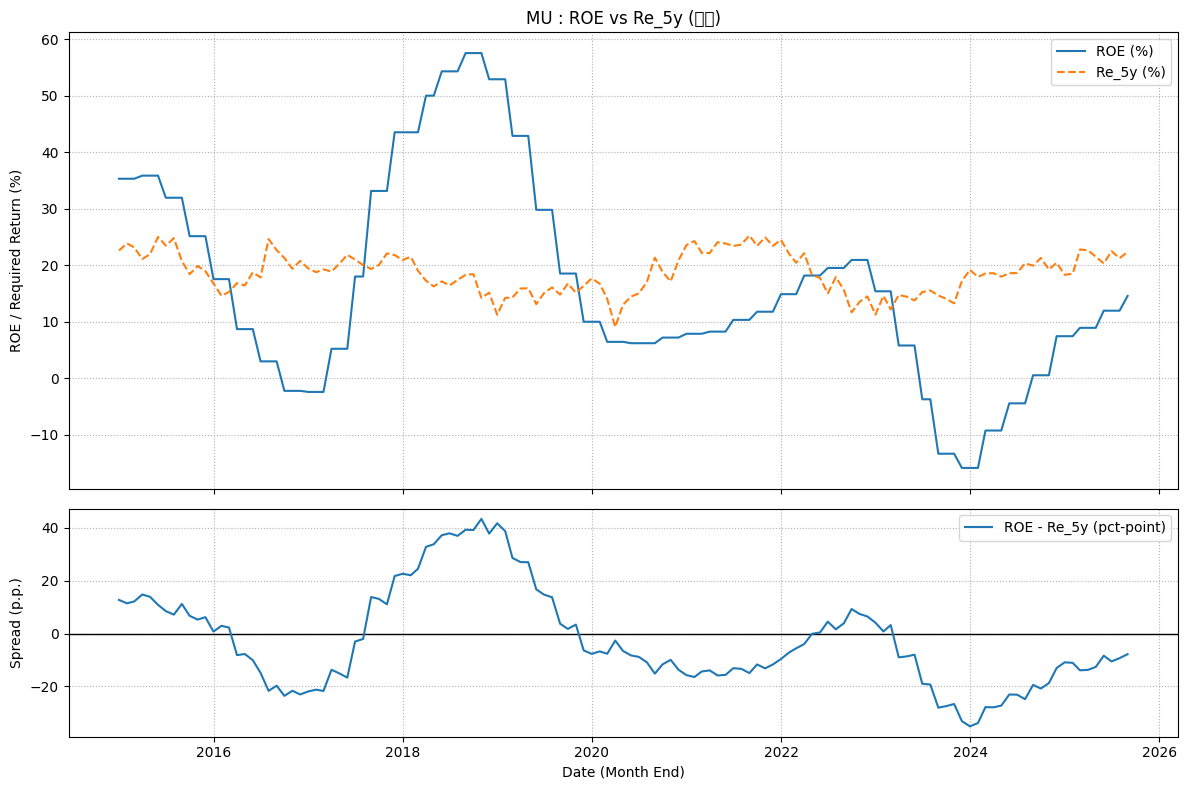

In [7]:
plot_roe_re_spread(
    db_info=db_info,
    ticker= ticker
)

In [8]:
merged_monthly, ri_table, fair_value = run_rim_valuation_from_db(
    db_info=db_info,
    ticker= ticker,
    payout_ratio=0.0,
    n_high_years=30,
    n_fade_years=1,
    terminal_spread=0.0
)

print("RIM Fair Value =", fair_value)
print(ri_table.head())

[INFO] MU 최신 Book Value(stockholders_equity): 54,165,000,000
[INFO] MU 최신 월말 기준
       ROE      = 0.1455
       Re_5y    = 0.2234
       spread   = -0.0779
       Book Value = 54,165,000,000
RIM Fair Value = 7518243329.670074
   year    begin_book     ROE_t    earnings_t  div_t      end_book  \
0     1  5.416500e+10  0.145484  7.880141e+09    0.0  6.204514e+10   
1     2  6.204514e+10  0.145484  9.026575e+09    0.0  7.107172e+10   
2     3  7.107172e+10  0.145484  1.033980e+10    0.0  8.141151e+10   
3     4  8.141151e+10  0.145484  1.184407e+10    0.0  9.325559e+10   
4     5  9.325559e+10  0.145484  1.356720e+10    0.0  1.068228e+11   

           RI_t  discount_factor       PV_RI_t     cum_PV_RI  
0 -4.221434e+09         0.817380 -3.450517e+09 -3.450517e+09  
1 -4.835585e+09         0.668111 -3.230706e+09 -6.681223e+09  
2 -5.539085e+09         0.546101 -3.024898e+09 -9.706121e+09  
3 -6.344933e+09         0.446372 -2.832200e+09 -1.253832e+10  
4 -7.268019e+09         0.364856 -2.65

In [109]:
print(fair_value/1000000000)

63.169178122198595


In [20]:
roe_list =[0.50,0.50,0.50,0.50,0.50,
           0.35,0.35,0.35,0.35,0.35,
           0.25,0.25,0.25,0.25,0.25,
           0.25,0.25,0.25,0.25,0.25,
           0.25,0.25,0.25,0.25,0.25,
           0.25,0.25,0.25,0.25,0.25,
]

B0 =  58806000000  # 예: 10억 (달러 단위 그대료)
r  = 0.22            # 요구수익률 12%
payout = 0.0

ri_table, V0 = rim_valuation_from_roe_list(
    roe_list=roe_list,
    initial_book_value=B0,
    required_return=r,
    payout_ratio=payout,
    terminal_spread=0.00,          # 안정기 ROE = r + 0.00
    terminal_method="ri_perpetuity"
)

print(ri_table.head())
print("Terminal PV0:", ri_table.attrs["terminal_value_PV0"])
print("Fair Value V0:", V0)

   year    begin_book  ROE_t    earnings_t  div_t      end_book          RI_t  \
0     1  5.880600e+10    0.5  2.940300e+10    0.0  8.820900e+10  1.646568e+10   
1     2  8.820900e+10    0.5  4.410450e+10    0.0  1.323135e+11  2.469852e+10   
2     3  1.323135e+11    0.5  6.615675e+10    0.0  1.984702e+11  3.704778e+10   
3     4  1.984702e+11    0.5  9.923512e+10    0.0  2.977054e+11  5.557167e+10   
4     5  2.977054e+11    0.5  1.488527e+11    0.0  4.465581e+11  8.335751e+10   

   discount_factor       PV_RI_t     cum_PV_RI  
0         0.819672  1.349646e+10  1.349646e+10  
1         0.671862  1.659401e+10  3.009047e+10  
2         0.550707  2.040247e+10  5.049293e+10  
3         0.451399  2.508500e+10  7.557793e+10  
4         0.369999  3.084221e+10  1.064201e+11  
Terminal PV0: 0.0
Fair Value V0: 445607115675.56805


In [21]:
V0/1000000000

445.6071156755681

In [21]:
B0 = 12520300000   # 현재 장부가치
roe = 0.40             # 15%
r   = 0.17            # 최신 요구수익률 9.5%
g   = 0.15         # 내가 가정한 장기 성장률 5%


res = rim_perpetual_spread_custom_g(B0, roe, r, g)
print(res)

{'B0': 12520300000, 'ROE': 0.4, 'r': 0.17, 'g': 0.15, 'spread(ROE - r)': 0.23, 'r_minus_g': 0.020000000000000018, 'value(V0)': 156503749999.99988}


In [22]:
res['value(V0)']/1000000000

156.50374999999988

In [20]:
res

{'B0': 386867000000,
 'ROE': 0.3,
 'r': 0.14,
 'g': 0.05,
 'spread(ROE - r)': 0.15999999999999998,
 'r_minus_g': 0.09000000000000001,
 'value(V0)': 1074630555555.5553}

In [12]:
book_value = get_latest_book_value_from_sec_financial(
    db_info=db_info,
    ticker=ticker,
    item_name="stockholders_equity"
)
print(book_value)

[INFO] MU 최신 Book Value(stockholders_equity): 54,165,000,000
54165000000.0
